# Clasificación de imágenes en color utilizando transfer learning con ResNet50



In [1]:
# <Importación de bibliotecas
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

##Lectura del dataset

In [2]:
import tensorflow as tf
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Ruta al directorio en Google Drive donde están las imágenes
drive_path = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/datos_U5L31/'

# Crear un generador de datos de imágenes desde el directorio en Google Drive
image_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
data_generator = image_generator.flow_from_directory(
    directory=drive_path,
    target_size=(224, 224),
    batch_size=256,
    class_mode='categorical'
)

# Verificar las clases encontradas
print(data_generator.class_indices)

Mounted at /content/drive
Found 169 images belonging to 2 classes.
{'gato': 0, 'perro': 1}


## Análisis del dataset

In [3]:
# Veamos cuántas imágenes hay por cada categoría
categories = os.listdir(drive_path)

# Lo guardaremos en un diccionario
dogs_counts = {}

# Iteramos por cada categoría
for category in categories:
    category_path = os.path.join(drive_path, category)
    if os.path.isdir(category_path):
        # Contamos el número de imágenes dentro de cada categoría
        num_files = len(os.listdir(category_path))
        dogs_counts[category] = num_files

# Mostramos el recuento
print("Animales por categoría")
for category, count in dogs_counts.items():
    print(f"{category}: {count} imágenes")

Animales por categoría
gato: 82 imágenes
perro: 87 imágenes


In [4]:
# Creamos el conjunto de datos de entrenamiento y validación
train_ds = image_dataset_from_directory(
    drive_path,
    validation_split=0.2,
    subset="training",
    seed=1234,
    image_size=(224, 224),
    batch_size=256,
)

val_ds = image_dataset_from_directory(
    drive_path,
    validation_split=0.2,
    subset="validation",
    seed=1234,
    image_size=(224, 224),
    batch_size=256,
)

Found 169 files belonging to 2 classes.
Using 136 files for training.
Found 169 files belonging to 2 classes.
Using 33 files for validation.


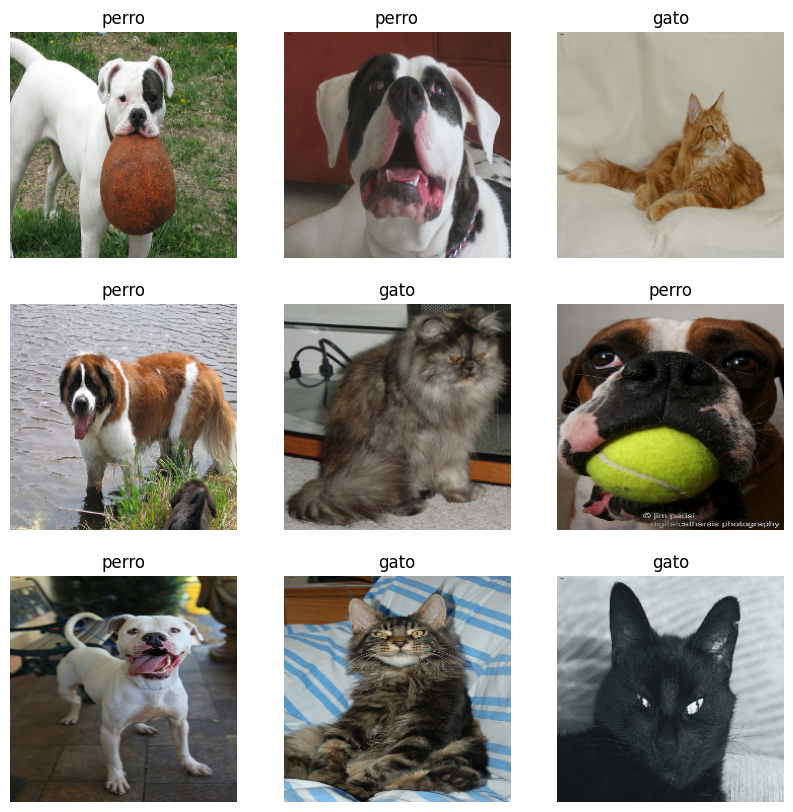

In [5]:
# Ahora visualizaremos algunas imágenes a modo de ejemplo.

# Definimos las etiquetas de las clases
class_names = train_ds.class_names

# Iteramos sobre el conjunto de validación y mostramos algunas imágenes
for images, labels in val_ds.take(1):  # Tomamos solo el primer batch para el ejemplo
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Mostramos 9 imágenes
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## Cargamos el modelo y lo entrenamos

In [6]:
# Cargamos el modelo ResNet preentrenado con 'imagenet'
base_model = ResNet50(weights='imagenet', include_top=False)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# Congelamos las capas base del modelo preentrenado
base_model.trainable = False

# Construimos el modelo de clasificación sobre el modelo base
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = Flatten()(x)
outputs = Dense(2, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       200,706 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,788,418 (90.75 MB)

 Trainable params: 200,706 (784.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
# Compilamos el modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo
model.fit(train_ds, validation_data=val_ds, epochs=5, batch_size=10)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 66s 66s/step - accuracy: 0.4191 - loss: 1.7012 - val_accuracy: 0.4545 - val_loss: 16.3174
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - accuracy: 0.5735 - loss: 9.2271 - val_accuracy: 0.8788 - val_loss: 1.1583
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - accuracy: 0.9926 - loss: 0.0707 - val_accuracy: 0.9091 - val_loss: 1.5203
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - accuracy: 0.9485 - loss: 0.3889 - val_accuracy: 0.8788 - val_loss: 3.1775
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - accuracy: 0.8971 - loss: 1.2644 - val_accuracy: 0.8788 - val_loss: 3.4617


## Obtención de métricas

In [9]:
# Evaluamos el modelo
loss, accuracy = model.evaluate(val_ds)
print(f'Pérdida: {loss}, Precisión: {accuracy}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8788 - loss: 3.4617
Pérdida: 3.461728811264038, Precisión: 0.8787878751754761


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


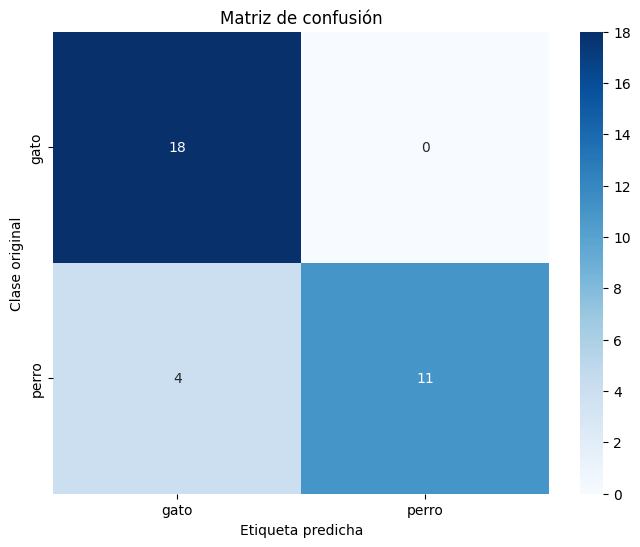

In [10]:
# Obtenemos los nombres de las etiquetas
true_labels = []
predicted_labels = []
imagenes = []

for imgs, labels in val_ds:
    true_labels.extend(labels.numpy())
    imagenes.extend(imgs)
    # Obtenemos las predicciones en el conjunto de validación
    predicted_probs = model.predict(imgs)
    predicted_labels.extend(np.argmax(predicted_probs, axis=1))

# Mostramos la matriz de confusión
conf_matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Etiqueta predicha')
plt.ylabel('Clase original')
plt.title('Matriz de confusión')
plt.show()

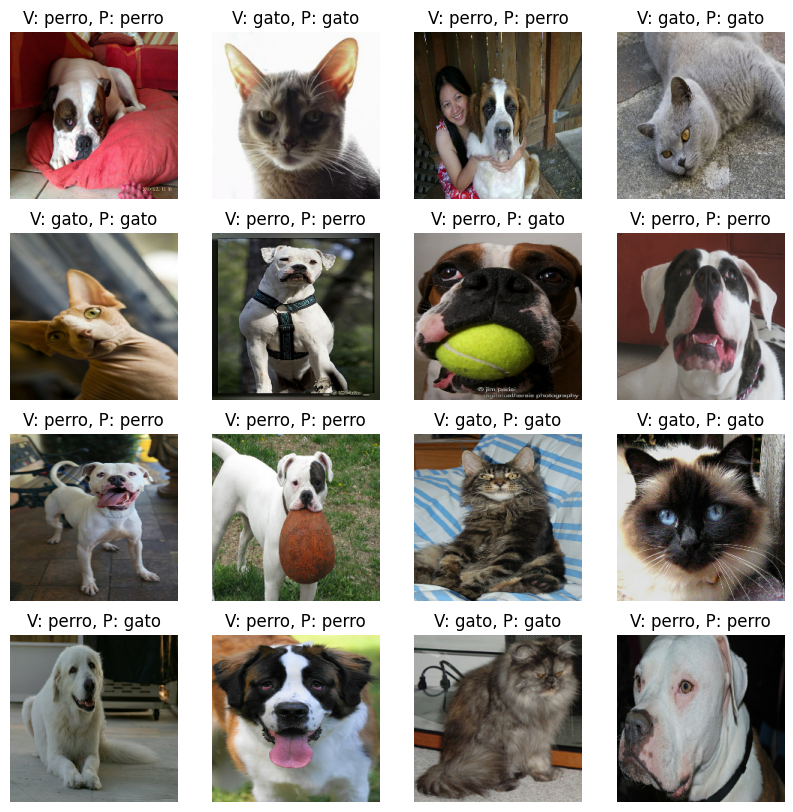

In [11]:
# Mostramos algunas imágenes para ver si las predicciones han sido correctas
plt.figure(figsize=(10, 10))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(imagenes[i].numpy().astype("uint8"))
    plt.title(f"V: {class_names[true_labels[i]]}, P: {class_names[predicted_labels[i]]}")
    plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


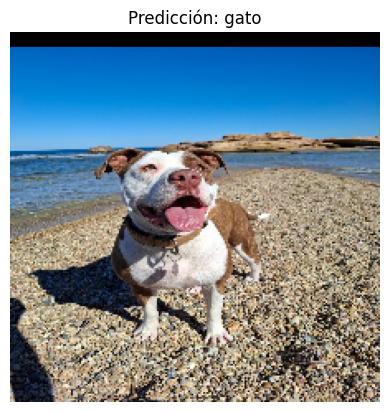

In [12]:
# Importar las bibilitoecas necesarias
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Definir las clases (etiquetas) del modelo
class_names = train_ds.class_names

# Función para cargar, preprocesar y hacer una predicción sobre una imagen
def predecir_imagen(ruta_imagen, model):
    # Cargar la imagen
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    # Convertir la imagen a un array numpy y normalizar
    img_array = image.img_to_array(img) / 255.0
    # Añadir una dimensión adicional para crear un batch (el modelo espera un batch de imágenes)
    img_batch = np.expand_dims(img_array, axis=0)
    # Hacer la predicción con el modelo
    prediccion = model.predict(img_batch)
    # Obtener el índice de la categoría predicha
    indice_clase_predicha = np.argmax(prediccion)
    # Obtener el nombre de la clase predicha
    clase_predicha = class_names[indice_clase_predicha]

    return img, clase_predicha

# Ruta a tu imagen (cambia por la tuya)
ruta_mi_imagen = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/Gina.jpeg'

# Hacer la predicción con la imagen
img_predicha, clase_predicha = predecir_imagen(ruta_mi_imagen, model)

# Mostrar la imagen y la clase predicha
plt.figure()
plt.imshow(img_predicha)
plt.title(f'Predicción: {clase_predicha}')
plt.axis('off')
plt.show()

La predicción del modelo dice que un pitbull es un gato, así que vamos a comprobar qué diría ResNet50 tal como está preentrenada con el conjunto de datos ImageNet, sin ningún entrenamiento adicional.

In [13]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

# Ruta a la imagen que quieres probar
img_path = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/Gina.jpeg'

# Carga y prepara la imagen
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Carga el modelo ResNet50 preentrenado (sin modificar)
model_resnet = ResNet50(weights='imagenet')

# Predicción
preds = model_resnet.predict(x)

# Mostrar las 5 clases más probables
decoded = decode_predictions(preds, top=5)[0]
for i, (imagenet_id, label, prob) in enumerate(decoded):
    print(f"{i+1}. {label} ({imagenet_id}) - Probabilidad: {prob:.2f}")



102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1. French_bulldog (n02108915) - Probabilidad: 0.36
2. American_Staffordshire_terrier (n02093428) - Probabilidad: 0.24
3. Staffordshire_bullterrier (n02093256) - Probabilidad: 0.16
4. pug (n02110958) - Probabilidad: 0.06
5. Boston_bull (n02096585) - Probabilidad: 0.06


ResNet50 original, entrenada con ImageNet, reconoce claramente la imagen como un perro.
Todas las etiquetas del top-5 son razas de perro: French_bulldog, American_Staffordshire_terrier, Staffordshire_bullterrier, pug, Boston_bull.

El problema no está en el modelo preentrenado ResNet50, sino en el modelo adaptado mediante transfer learning.
Parece que el modelo entrenado ha perdido información visual relevante para diferenciar gatos y perros. Esto puede deberse a una falta de variedad en el conjunto de datos, a un sobreajuste a patrones visuales incorrectos o bien a que la clase "perro" se ha representado de forma demasiado limitada durante el entrenamiento.

Anem a fer una prova de fine-tuning a les últimes capes de ResNet per permetre al model adaptar millor les seves característiques.

## Fine tuning

In [14]:
# Descongelamos las últimas 30 capas del modelo base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilamos el modelo con una tasa de aprendizaje más baja
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos de nuevo con fine-tuning
print("Entrenando con fine-tuning (últimas 30 capas descongeladas)...")
model.fit(train_ds, validation_data=val_ds, epochs=3, batch_size=10)

# Nueva evaluación después del fine-tuning
loss, accuracy = model.evaluate(val_ds)
print(f'Pérdida tras el fine-tuning: {loss:.4f}, Precisión: {accuracy:.4f}')

Entrenando con fine-tuning (últimas 30 capas descongeladas)...
Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 56s 56s/step - accuracy: 0.9559 - loss: 0.3643 - val_accuracy: 0.8788 - val_loss: 3.3081
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 85s 85s/step - accuracy: 0.9853 - loss: 0.1321 - val_accuracy: 0.8788 - val_loss: 3.2007
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 81s 81s/step - accuracy: 0.9926 - loss: 0.0745 - val_accuracy: 0.8788 - val_loss: 3.1231
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8788 - loss: 3.1231
Pérdida tras el fine-tuning: 3.1231, Precisión: 0.8788


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


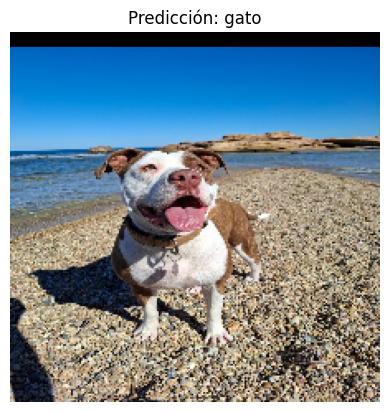

In [15]:
# Definir las clases (etiquetas) del modelo
class_names = train_ds.class_names

# Función para cargar, preprocesar y hacer una predicción sobre una imagen
def predecir_imagen(ruta_imagen, modelo):
    # Cargar la imagen
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    # Convertir la imagen a un array numpy y normalizar
    img_array = image.img_to_array(img) / 255.0
    # Añadir una dimensión adicional para crear un batch (el modelo espera un batch de imágenes)
    img_batch = np.expand_dims(img_array, axis=0)
    # Hacer la predicción con el modelo
    prediccion = modelo.predict(img_batch)
    # Obtener el índice de la categoría predicha
    indice_clase_predicha = np.argmax(prediccion)
    # Obtener el nombre de la clase predicha
    clase_predicha = class_names[indice_clase_predicha]

    return img, clase_predicha

# Ruta a tu imagen (cambia por la tuya)
ruta_mi_imagen = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/Gina.jpeg'

# Hacer la predicción con la imagen
img_predicha, clase_predicha = predecir_imagen(ruta_mi_imagen, model)

# Mostrar la imagen y la clase predicha
plt.figure()
plt.imshow(img_predicha)
plt.title(f'Predicción: {clase_predicha}')
plt.axis('off')
plt.show()

# Conclusiones
Aunque el modelo entrenado con ResNet50 obtiene una alta precisión en las imágenes del conjunto de validación, sigue confundiendo la imagen de un pitbull con un gato, incluso después de ajustar las últimas capas. Esto indica que el modelo ha aprendido a distinguir entre gatos y perros según el tipo de imágenes vistas durante el entrenamiento, pero no ha tenido suficiente variedad dentro de la clase "perro".
Por este motivo, un perro con una apariencia diferente (como un pitbull) puede ser clasificado erróneamente.
También hemos comprobado que la ResNet50 original, sin haber sido entrenada con nuestro dataset, sí reconoce correctamente al pitbull como un perro. Esto sugiere que el problema no está en el modelo base, sino en cómo lo hemos entrenado.

Para mejorar el resultado, sería necesario añadir más imágenes de perros variados, aplicar técnicas de aumento de datos, o incluso aprovechar directamente la salida del modelo original con las 1.000 clases de ImageNet.

Se podrían hacer más pruebas, pero el coste computacional es bastante elevado.



# Más Pruebas con fine-tuning y aumento de datos

In [17]:
"""
La augmentación no añade imágenes nuevas al dataset, pero genera versiones distintas
de cada imagen en cada época mediante transformaciones aleatorias.
Así, si entrenas 10 épocas, el modelo puede ver hasta 10 versiones distintas por imagen.
"""

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

# Augmentación solo para el conjunto de entrenamiento
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

# Base del modelo preentrenado
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Solo entrenamos las últimas 50 capas
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Definimos el nuevo model2
inputs = tf.keras.Input(shape=(224, 224, 3))                # Entrada del modelo: imágenes RGB de 224x224
x = data_augmentation(inputs)                               # Aplicamos augmentación de datos solo durante el entrenamiento
x = base_model(x, training=True)                            # Pasamos la imagen por la ResNet50 preentrenada (últimas capas descongeladas)
x = layers.GlobalAveragePooling2D()(x)                      # Reducimos cada mapa de activación a un solo valor (mejor que Flatten)
x = layers.Dense(128, activation='relu')(x)                 # Capa densa intermedia con activación ReLU para aprender patrones más complejos
x = layers.Dropout(0.3)(x)                                  # Dropout del 30% para evitar sobreajuste
outputs = layers.Dense(2, activation='softmax')(x)          # Capa de salida con 2 neuronas (una por clase), usando softmax
model2 = tf.keras.Model(inputs, outputs)                    # Definimos el modelo final conectando entrada y salida

# Compilamos con una tasa de aprendizaje baja para fine-tuning
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Entrenamiento
print("Entrenando model2 con augmentación y fine-tuning (últimas 50 capas)...")
history = model2.fit(train_ds, validation_data=val_ds, epochs=10)

# Evaluación final
loss, accuracy = model2.evaluate(val_ds)
print(f'Pérdida final: {loss:.4f}, Precisión: {accuracy:.4f}')


Entrenando model2 con augmentación y fine-tuning (últimas 50 capas)...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68s/step - accuracy: 0.5074 - loss: 1.3050

1/1 ━━━━━━━━━━━━━━━━━━━━ 78s 78s/step - accuracy: 0.5074 - loss: 1.3050 - val_accuracy: 0.5455 - val_loss: 1.0155
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 48s 48s/step - accuracy: 0.4926 - loss: 1.2274 - val_accuracy: 0.5152 - val_loss: 0.9400
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 81s 81s/step - accuracy: 0.5000 - loss: 1.1269 - val_accuracy: 0.4848 - val_loss: 0.8718
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 88s 88s/step - accuracy: 0.4853 - loss: 1.0984 - val_accuracy: 0.5455 - val_loss: 0.8114
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 48s 48s/step - accuracy: 0.4926 - loss: 0.9705 - val_accuracy: 0.5455 - val_loss: 0.7568
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 82s 82s/step - accuracy: 0.5515 - loss: 0.8559 - val_accuracy: 0.6061 - val_loss: 0.7077
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 82s 82s/step - accuracy: 0.5515 - loss: 0.9294 - val_accuracy: 0.6364 - val_loss: 0.6649
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 82s 82s/step - accuracy: 0.5368 - loss: 0.8417 - val_accuracy: 0.6970 - val_loss: 0.6278
Epoch 9/10


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


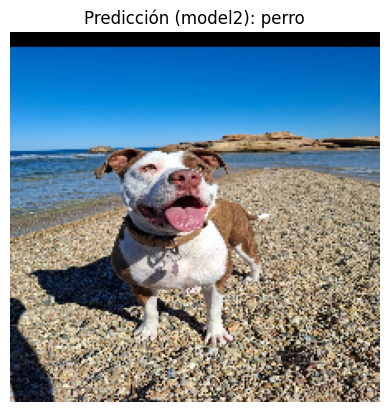

In [18]:
# Definir las clases (etiquetas) del modelo2
class_names = train_ds.class_names

# Función para cargar, preprocesar y hacer una predicción sobre una imagen usando model2
def predecir_imagen(ruta_imagen, modelo):
    # Cargar la imagen
    img = image.load_img(ruta_imagen, target_size=(224, 224))
    # Convertir la imagen a un array numpy y normalizar
    img_array = image.img_to_array(img) / 255.0
    # Añadir una dimensión adicional para crear un batch
    img_batch = np.expand_dims(img_array, axis=0)
    # Hacer la predicción
    prediccion = modelo.predict(img_batch)
    # Obtener el índice y la etiqueta
    indice_clase_predicha = np.argmax(prediccion)
    clase_predicha = class_names[indice_clase_predicha]

    return img, clase_predicha

# Ruta a tu imagen (puedes cambiarla)
ruta_mi_imagen = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/Gina.jpeg'

# Hacer la predicción usando model2
img_predicha, clase_predicha = predecir_imagen(ruta_mi_imagen, model2)

# Mostrar la imagen y la predicción
plt.figure()
plt.imshow(img_predicha)
plt.title(f'Predicción (model2): {clase_predicha}')
plt.axis('off')
plt.show()

Hemos entrenado un modelo de clasificación de imágenes usando transfer learning con ResNet50. Inicialmente, congelamos la base y entrenamos solo las capas superiores, pero el modelo confundía perros con gatos, incluso razas claras como el pitbull.

Para mejorar, aplicamos fine-tuning descongelando las últimas 50 capas de ResNet50 y añadimos data augmentation para aumentar la variabilidad del conjunto de entrenamiento. Entrenamos el nuevo modelo (model2) con una tasa de aprendizaje baja y más épocas. El resultado: el modelo fue capaz de corregir errores anteriores y clasificar correctamente imágenes que antes fallaba.

Esto demuestra que el modelo base era bueno, pero necesitaba una mejor adaptación a los datos concretos.